In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_loan = pd.read_csv('../data/loan_data.csv')

In [3]:
df_loan_vf = df_loan.copy()

In [4]:
df_loan_vf = df_loan_vf.rename(columns={
    'Gender': 'Genre',
    'Married': 'Marier',
    'Dependents': 'Personnes_a_charge',
    'Education': 'Niveau_etude',
    'Self_Employed': 'Independant',
    'ApplicantIncome': 'Revenu_demandeur',
    'CoapplicantIncome': 'Revenu_co_demandeur',
    'LoanAmount': 'Montant_pret',
    'Loan_Amount_Term': 'Duree_pret',
    'Credit_History': 'Historique_credit',
    'Property_Area': 'Zone_habitation',
    'Loan_Status': 'Statut_pret'
})

In [5]:
df_loan_vf

,Loan_ID,Genre,Marier,Personnes_a_charge,Niveau_etude,Independant,Revenu_demandeur,Revenu_co_demandeur,Montant_pret,Duree_pret,Historique_credit,Zone_habitation,Statut_pret
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,NaN
977,LP002975,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,NaN
978,LP002980,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,NaN
979,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN


In [6]:
df_loan_vf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Loan_ID              981 non-null    object 
 1   Genre                957 non-null    object 
 2   Marier               978 non-null    object 
 3   Personnes_a_charge   956 non-null    object 
 4   Niveau_etude         981 non-null    object 
 5   Independant          926 non-null    object 
 6   Revenu_demandeur     981 non-null    int64  
 7   Revenu_co_demandeur  981 non-null    float64
 8   Montant_pret         954 non-null    float64
 9   Duree_pret           961 non-null    float64
 10  Historique_credit    902 non-null    float64
 11  Zone_habitation      981 non-null    object 
 12  Statut_pret          614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB


In [7]:
df_loan_vf.describe()

,Revenu_demandeur,Revenu_co_demandeur,Montant_pret,Duree_pret,Historique_credit
count,981.000000,981.000000,954.000000,961.000000,902.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920
std,5695.104533,2718.772806,77.421743,65.100602,0.370553
min,0.000000,0.000000,9.000000,6.000000,0.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [8]:
df_loan_vf["Statut_pret"].value_counts()

Statut_pret
Y    422
N    192
Name: count, dtype: int64

In [9]:
df_loan_vf["Statut_pret"].isna().sum()
# On a 367 valeurs manquantes dans cette colonnes, ce qui représente 1/3 du dataset
# et peut fausser notre modèle de machin learning on doit impérativement
# trouver un moyen de combler ces valeurs 

# Décision : Ignorez les lignes sans statut pret et se concentrer sur celles qui en ont. 

np.int64(367)

## Visualisation du dataset

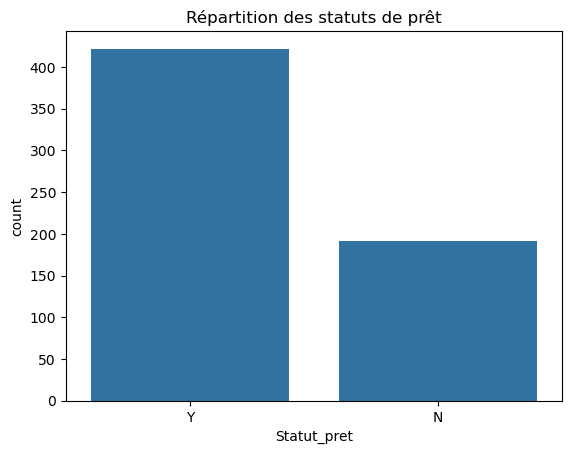

In [10]:
#Repartition des réponses à la demande de prêt
sns.countplot(x='Statut_pret', data=df_loan_vf)
plt.title("Répartition des statuts de prêt")
plt.show()

Déséquilibre entre les deux classes, environ 422 prêts accordés (Y) contre 192 refusés (N) donc à peu près 69% / 31%. 
Rappel : l'accuracy seule pourrait donner une impression trompeuse, un modèle qui prédirait toujours "Y" aurait déjà environ 69% de bonnes réponses sans avoir rien appris.

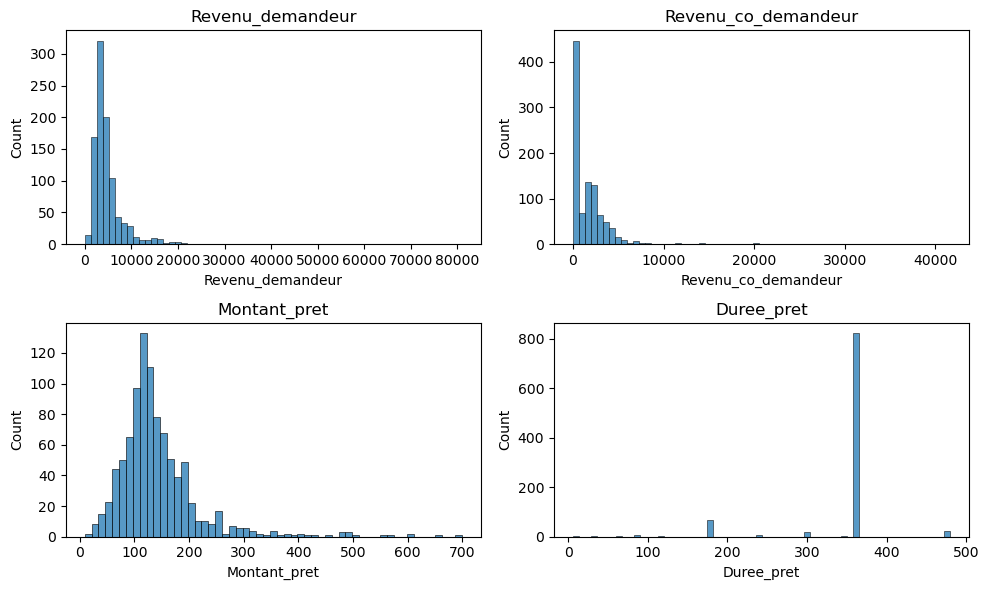

In [11]:
#Distribution des valeurs numériques
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
colonnes = ['Revenu_demandeur', 'Revenu_co_demandeur', 'Montant_pret', 'Duree_pret']

for ax, col in zip(axes.flatten(), colonnes):
    sns.histplot(df_loan_vf[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Pour Revenu demandeur et Revenu co demandeur, faire une transformation logarithmique car valeurs trop entendu.
Durée pret : On peut la categoriser ou la laisser tel qu'elle. A reflechir. 
Montant prêt : En cloche et lisible. Peut etre legerement etendu. 

In [12]:
df_loan_vf['Duree_pret'].value_counts().sort_index()

Duree_pret
6.0        1
12.0       2
36.0       3
60.0       3
84.0       7
120.0      4
180.0     66
240.0      8
300.0     20
350.0      1
360.0    823
480.0     23
Name: count, dtype: int64

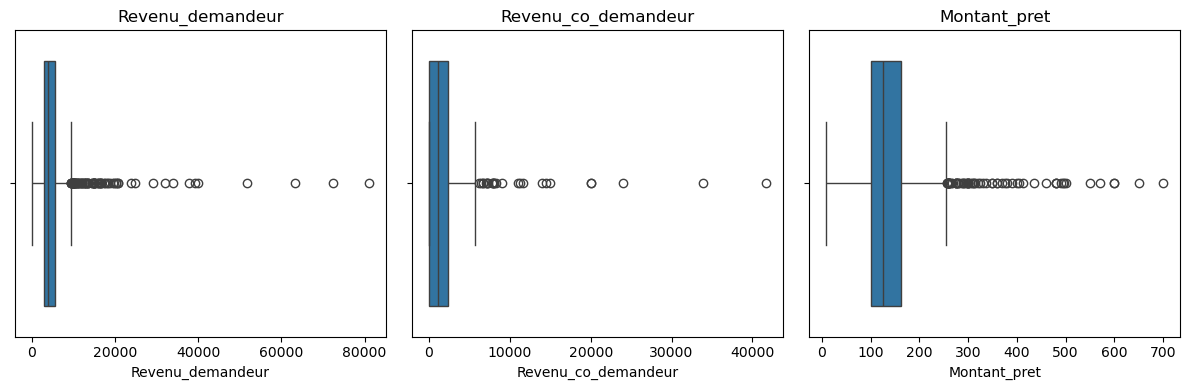

In [13]:
# Visu en boxplot des valeurs aberante 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colonnes = ['Revenu_demandeur', 'Revenu_co_demandeur', 'Montant_pret']

for ax, col in zip(axes, colonnes):
    sns.boxplot(x=df_loan_vf[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Revenu_demandeur a le plus de points aberrants, étalés jusqu'à environ 80000. Revenu_co_demandeur en a un peu moins, mais avec le même schéma, jusqu'à environ 40000. Montant_pret est un peu moins extrême proportionnellement, mais garde quand même une traîne assez longue jusqu'à 700.

Confirmation de la future transformation logarithmique

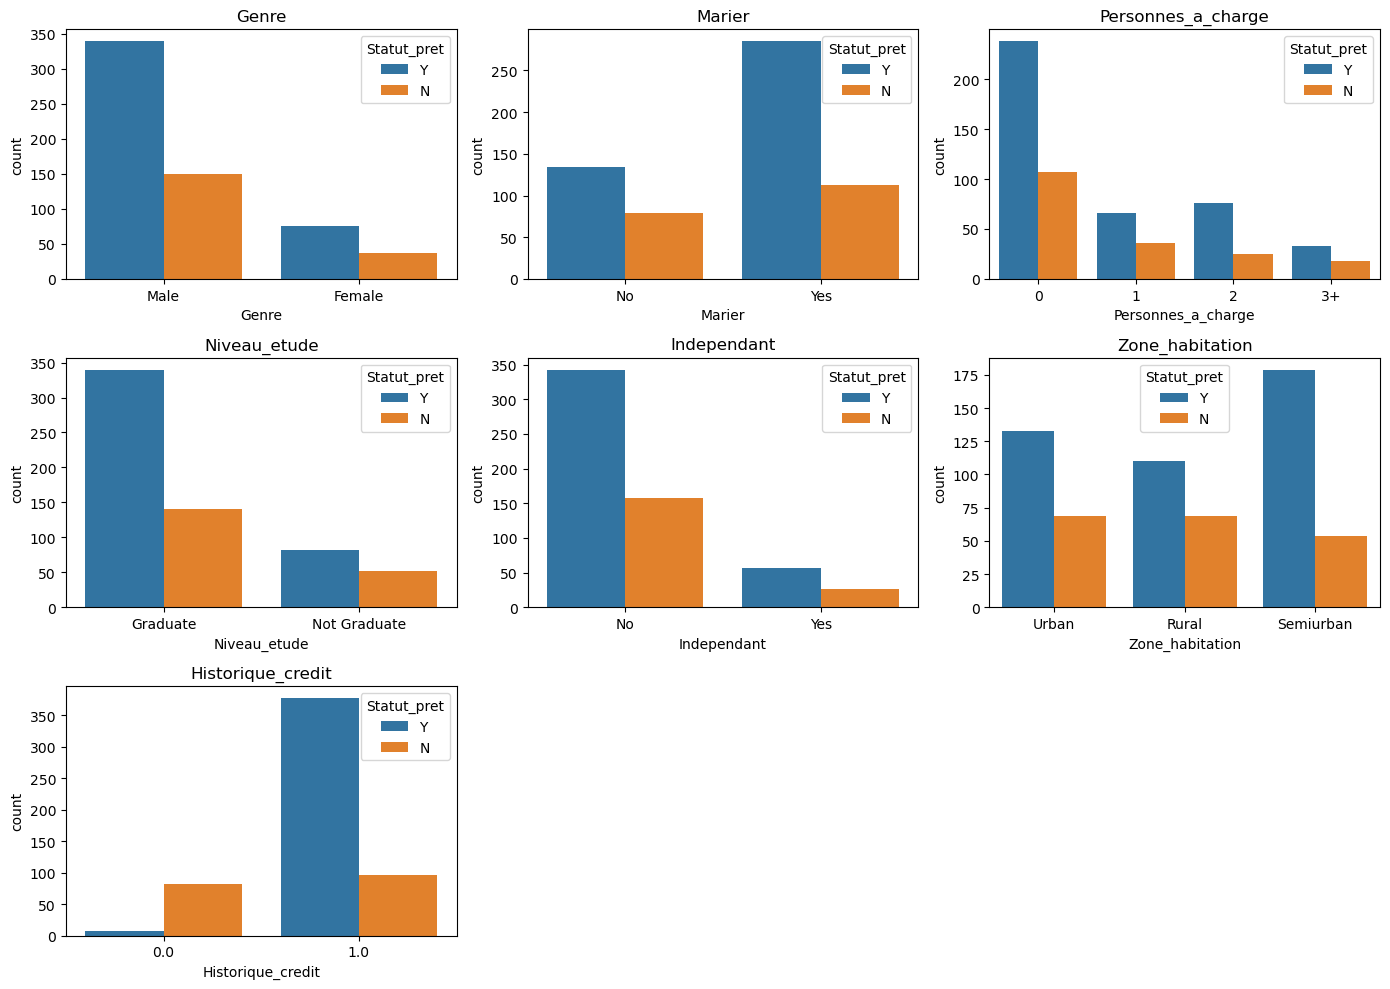

In [14]:
#
colonnes_cat = ['Genre', 'Marier', 'Personnes_a_charge', 'Niveau_etude', 'Independant', 'Zone_habitation', 'Historique_credit']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, colonnes_cat):
    sns.countplot(x=col, hue='Statut_pret', hue_order=['Y', 'N'], data=df_loan_vf, ax=ax)
    ax.set_title(col)

for ax in axes[len(colonnes_cat):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Historique_credit ressort clairement comme le facteur le plus déterminant. Quand Historique_credit = 0, quasiment aucun prêt n'est accordé.

Zone_habitation montre une petite différence, Semiurban a une proportion de Y un peu plus élevée que Urban et Rural, mais c'est plus discret que Historique_credit.

Genre, Marier, Niveau_etude, Independant, Personnes_a_charge montrent tous à peu près la même proportion Y/N dans chaque catégorie, pas de vrai écart visible à l'œil. Ça ne veut pas dire qu'elles n'auront aucun poids dans le modèle, mais elles ne se détachent pas comme facteur de risque évident sur ce simple comptage visuel.



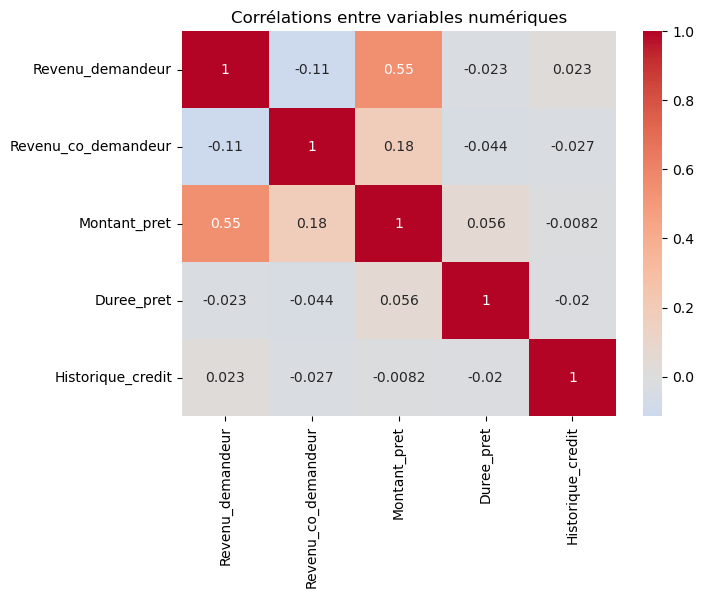

In [15]:
#Corrélation des variables numériques 
colonnes_num = ['Revenu_demandeur', 'Revenu_co_demandeur', 'Montant_pret', 'Duree_pret', 'Historique_credit']

plt.figure(figsize=(7, 5))
sns.heatmap(df_loan_vf[colonnes_num].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Corrélations entre variables numériques")
plt.show()

Une seule corrélation ressort vraiment, Revenu_demandeur et Montant_pret à 0.55, plutôt logique, plus le demandeur gagne, plus il emprunte un montant élevé. C'est modéré, pas au point de dire que les deux racontent exactement la même chose, donc pas besoin d'en supprimer une pour l'instant.

Revenu_co_demandeur et Montant_pret ont une corrélation plus faible, 0.18, un lien léger mais bien moins marqué. Toutes les autres paires sont proches de 0, quasiment aucun lien entre elles.

Le point important : absence de signal, Historique_credit ne montre aucune corrélation avec les autres variables numériques (tout est proche de 0), alors qu'on venait de voir sur les countplots que c'était justement le facteur le plus déterminant pour prédire Statut_pret. Ça illustre bien la limite d'une matrice de corrélation classique, elle ne capte que les liens entre variables numériques entre elles, pas leur lien avec la cible catégorielle, qu'on avait déjà repéré à l'œil sur les countplots juste avant.

## Pré traitement des données

In [16]:
#Split du dataset en deux df. Mise de coté des lignes sans réponse au pret. 
df_avec_cible = df_loan_vf[df_loan_vf['Statut_pret'].notna()].copy()
df_sans_cible = df_loan_vf[df_loan_vf['Statut_pret'].isna()].copy()

In [17]:
# Vérification des doublons sur df_avec_cible
print("Doublons :", df_avec_cible.duplicated().sum())

Doublons : 0


In [22]:
# Encodage
# Genre, Marier, Independant : encodage binaire simple
df_avec_cible['Genre_encoded'] = df_avec_cible['Genre'].map({'Female': 0, 'Male': 1})
df_avec_cible['Marier_encoded'] = df_avec_cible['Marier'].map({'No': 0, 'Yes': 1})
df_avec_cible['Independant_encoded'] = df_avec_cible['Independant'].map({'No': 0, 'Yes': 1})

# Niveau_etude : Not Graduate = 0, Graduate = 1
df_avec_cible['Niveau_etude_encoded'] = df_avec_cible['Niveau_etude'].map({'Not Graduate': 0, 'Graduate': 1})

# Vérification que les NaN sont bien restés des NaN
for col in ['Genre', 'Marier', 'Independant', 'Niveau_etude']:
    print(col, "-> NaN avant:", df_avec_cible[col].isna().sum(), "| NaN après encodage:", df_avec_cible[col + '_encoded'].isna().sum())

Genre -> NaN avant: 13 | NaN après encodage: 13
Marier -> NaN avant: 3 | NaN après encodage: 3
Independant -> NaN avant: 32 | NaN après encodage: 32
Niveau_etude -> NaN avant: 0 | NaN après encodage: 0


In [27]:
df_avec_cible['Statut_pret_encoded'] = df_avec_cible['Statut_pret'].map({'N': 0, 'Y': 1})
print(df_avec_cible['Statut_pret_encoded'].value_counts())

Statut_pret_encoded
1    422
0    192
Name: count, dtype: int64


In [23]:
zone_encoded = pd.get_dummies(df_avec_cible['Zone_habitation'], prefix='Zone')
df_avec_cible = pd.concat([df_avec_cible, zone_encoded], axis=1)

df_avec_cible.filter(like='Zone').head()

,Zone_habitation,Zone_Rural,Zone_Semiurban,Zone_Urban
0,Urban,False,False,True
1,Rural,True,False,False
2,Urban,False,False,True
3,Urban,False,False,True
4,Urban,False,False,True


In [24]:
df_avec_cible['Personnes_a_charge_encoded'] = df_avec_cible['Personnes_a_charge'].replace('3+', 3).astype(float)
print("NaN avant:", df_avec_cible['Personnes_a_charge'].isna().sum(), "| NaN après:", df_avec_cible['Personnes_a_charge_encoded'].isna().sum())

NaN avant: 15 | NaN après: 15


In [25]:
pd.crosstab(df_avec_cible['Personnes_a_charge'], df_avec_cible['Statut_pret'], normalize='index') * 100

Statut_pret,N,Y
Personnes_a_charge,,
0,31.014493,68.985507
1,35.294118,64.705882
2,24.752475,75.247525
3+,35.294118,64.705882


## Split

In [28]:
colonnes_features = [
    'Genre_encoded', 'Marier_encoded', 'Personnes_a_charge_encoded', 'Niveau_etude_encoded',
    'Independant_encoded', 'Revenu_demandeur', 'Revenu_co_demandeur', 'Montant_pret',
    'Duree_pret', 'Historique_credit', 'Zone_Rural', 'Zone_Semiurban', 'Zone_Urban'
]

X = df_avec_cible[colonnes_features]
y = df_avec_cible['Statut_pret_encoded']

X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Genre_encoded               601 non-null    float64
 1   Marier_encoded              611 non-null    float64
 2   Personnes_a_charge_encoded  599 non-null    float64
 3   Niveau_etude_encoded        614 non-null    int64  
 4   Independant_encoded         582 non-null    float64
 5   Revenu_demandeur            614 non-null    int64  
 6   Revenu_co_demandeur         614 non-null    float64
 7   Montant_pret                592 non-null    float64
 8   Duree_pret                  600 non-null    float64
 9   Historique_credit           564 non-null    float64
 10  Zone_Rural                  614 non-null    bool   
 11  Zone_Semiurban              614 non-null    bool   
 12  Zone_Urban                  614 non-null    bool   
dtypes: bool(3), float64(8), int64(2)
memory 

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(491, 13) (123, 13)
Statut_pret_encoded
1    337
0    154
Name: count, dtype: int64
Statut_pret_encoded
1    85
0    38
Name: count, dtype: int64


## Nettoyage

- Données manquante
- Valeurs abérrante

In [39]:
#Traitement des données manquantes
print("Valeurs manquantes dans X_train :")
print(X_train.isna().sum())
print()
print("Valeurs manquantes dans X_test :")
print(X_test.isna().sum())

Valeurs manquantes dans X_train :
Genre_encoded                 0
Marier_encoded                0
Personnes_a_charge_encoded    0
Niveau_etude_encoded          0
Independant_encoded           0
Revenu_demandeur              0
Revenu_co_demandeur           0
Montant_pret                  0
Duree_pret                    0
Historique_credit             0
Zone_Rural                    0
Zone_Semiurban                0
Zone_Urban                    0
Revenu_demandeur_log          0
Revenu_co_demandeur_log       0
Montant_pret_log              0
dtype: int64

Valeurs manquantes dans X_test :
Genre_encoded                 0
Marier_encoded                0
Personnes_a_charge_encoded    0
Niveau_etude_encoded          0
Independant_encoded           0
Revenu_demandeur              0
Revenu_co_demandeur           0
Montant_pret                  0
Duree_pret                    0
Historique_credit             0
Zone_Rural                    0
Zone_Semiurban                0
Zone_Urban             

In [31]:
from sklearn.impute import SimpleImputer

colonnes_mode = ['Genre_encoded', 'Marier_encoded', 'Personnes_a_charge_encoded', 'Independant_encoded', 'Historique_credit']
colonnes_mediane = ['Montant_pret', 'Duree_pret']

imputer_mode = SimpleImputer(strategy='most_frequent')
imputer_mediane = SimpleImputer(strategy='median')

# Fit sur X_train uniquement, puis transform sur les deux
X_train[colonnes_mode] = imputer_mode.fit_transform(X_train[colonnes_mode])
X_test[colonnes_mode] = imputer_mode.transform(X_test[colonnes_mode])

X_train[colonnes_mediane] = imputer_mediane.fit_transform(X_train[colonnes_mediane])
X_test[colonnes_mediane] = imputer_mediane.transform(X_test[colonnes_mediane])

print("Valeurs manquantes restantes dans X_train :", X_train.isna().sum().sum())
print("Valeurs manquantes restantes dans X_test :", X_test.isna().sum().sum())

Valeurs manquantes restantes dans X_train : 0
Valeurs manquantes restantes dans X_test : 0


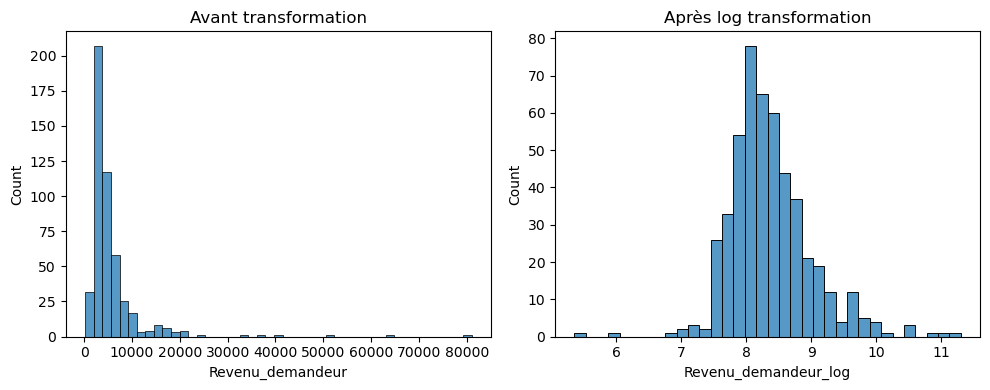

In [36]:
# Transformation logarithmique, réduit l'écart entre les valeurs extrêmes et le reste
# log1p plutôt que log pour gérer les valeurs à 0 sans erreur (log(0) n'existe pas)
colonnes_log = ['Revenu_demandeur', 'Revenu_co_demandeur', 'Montant_pret']

for col in colonnes_log:
    X_train[col + '_log'] = np.log1p(X_train[col])
    X_test[col + '_log'] = np.log1p(X_test[col])

# Visualisation avant / après sur X_train pour Revenu_demandeur
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(X_train['Revenu_demandeur'], ax=axes[0])
axes[0].set_title("Avant transformation")
sns.histplot(X_train['Revenu_demandeur_log'], ax=axes[1])
axes[1].set_title("Après log transformation")
plt.tight_layout()
plt.show()

In [40]:
# Standardisation  de Duree_pret uniquement, la seule colonne avec une échelle très différente des autres

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train['Duree_pret_std'] = scaler.fit_transform(X_train[['Duree_pret']])
X_test['Duree_pret_std'] = scaler.transform(X_test[['Duree_pret']])

X_train[['Duree_pret', 'Duree_pret_std']].describe()

,Duree_pret,Duree_pret_std
count,491.000000,4.910000e+02
mean,341.743381,-2.767644e-16
std,65.107943,1.001020e+00
min,12.000000,-5.069730e+00
25%,360.000000,2.806914e-01
50%,360.000000,2.806914e-01
75%,360.000000,2.806914e-01
max,480.000000,2.125664e+00
